# Prétraitement du Dataset FER2013
### Projet : Reconnaissance des Émotions Faciales — GL4 INSAT


### Méthodes de traitement d'image (Image Processing Methods)

This pipeline implements the following preprocessing steps:

1. **Nettoyage des données (Data Cleaning)**
   - Remove corrupted/unreadable images (cv2.imread validation)
   - Filter by image dimensions (minimum 40×40 px)
   - Remove low-contrast images (std dev < threshold)
   
2. **Redimensionnement (Resizing)**
   - Standardize all images to **48×48 pixels** (uniform input size)
   - Convert to **grayscale** (single channel, reduces computation)
   - Linear interpolation for quality preservation
   
3. **Normalization Only**
   - **Rescale**: Pixel values from [0-255] to [0-1] range
   - **NO augmentation here** - augmentation will be applied during training via PyTorch transforms
   
4. **Class Balancing**: Weighted loss using balanced class weights computed from training set
   
5. **Train/Validation Split**: 80/20 stratified split on training data

**Important:** Data augmentation (rotation, flips, zoom, shifts) is applied **at training time**, not during preprocessing. This ensures random variations each epoch.

## 0. Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

# Reproductibilite
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Chemins (adapter si besoin)
TRAIN_DIR = '../data/train'
TEST_DIR  = '../data/test'

# Parametres images
IMG_SIZE   = (48, 48)
BATCH_SIZE = 64

# Labels (ordre alphabetique = ordre detecte par Keras)
EMOTION_LABELS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
EMOTION_COLORS = ['#e74c3c','#8e44ad','#e67e22','#f1c40f','#95a5a6','#3498db','#1abc9c']

os.makedirs('../results', exist_ok=True)
os.makedirs('../data/preprocessed', exist_ok=True)

print('TensorFlow version :', tf.__version__)
print('GPU disponible     :', tf.config.list_physical_devices('GPU'))
print('Imports OK')

TensorFlow version : 2.21.0
GPU disponible     : []
Imports OK


---
## 1. Exploration initiale du dataset

In [2]:
def count_images(root_dir):
    """Compte le nombre d'images par sous-dossier (classe)."""
    counts = {}
    root = Path(root_dir)
    for class_dir in sorted(root.iterdir()):
        if class_dir.is_dir():
            n = len(list(class_dir.glob('*.jpg')) +
                    list(class_dir.glob('*.png')) +
                    list(class_dir.glob('*.jpeg')))
            counts[class_dir.name] = n
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print('=== Distribution des images ===')
print(f'{"Classe":<12} {"Train":>8} {"Test":>8} {"Total":>8}')
print('-' * 42)
total_train = total_test = 0
for cls in EMOTION_LABELS:
    tr = train_counts.get(cls, 0)
    te = test_counts.get(cls, 0)
    total_train += tr
    total_test  += te
    print(f'{cls:<12} {tr:>8} {te:>8} {tr+te:>8}')
print('-' * 42)
print(f'{"TOTAL":<12} {total_train:>8} {total_test:>8} {total_train+total_test:>8}')

ratio = max(train_counts.values()) / min(train_counts.values())
print(f'\nRatio max/min (train) : {ratio:.1f}x  -> desequilibre significatif')

=== Distribution des images ===
Classe          Train     Test    Total
------------------------------------------
angry            3995      958     4953
disgust           436      111      547
fear             4097     1024     5121
happy            7215     1774     8989
neutral          4965     1233     6198
sad              4830     1247     6077
surprise         3171      831     4002
------------------------------------------
TOTAL           28709     7178    35887

Ratio max/min (train) : 16.5x  -> desequilibre significatif


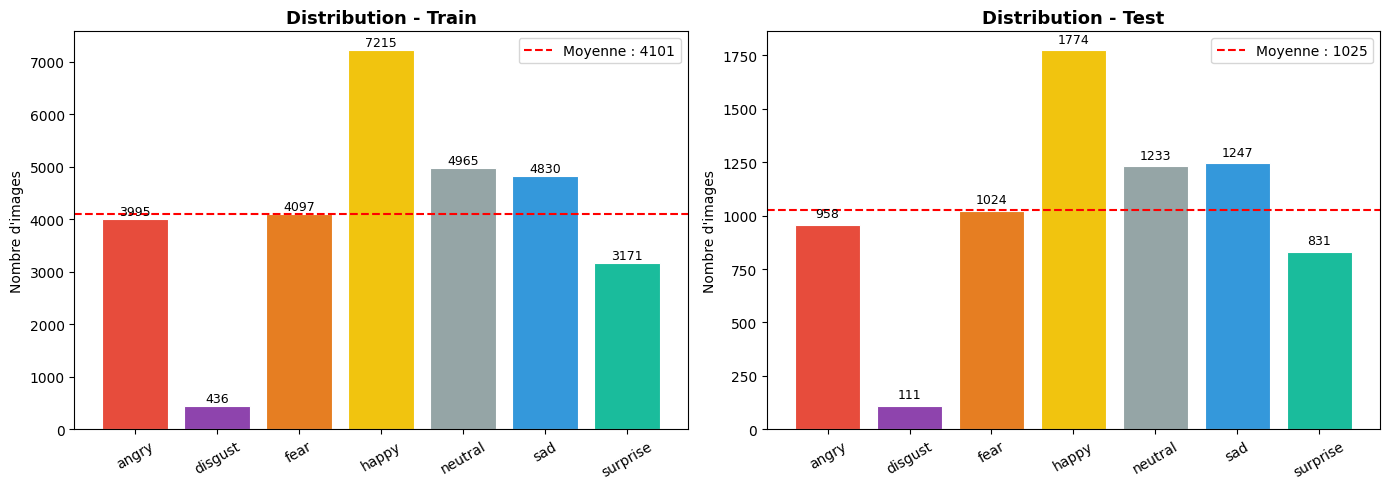

In [3]:
# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, counts) in zip(axes, [('Train', train_counts), ('Test', test_counts)]):
    classes = [c for c in EMOTION_LABELS if c in counts]
    values  = [counts[c] for c in classes]
    bars = ax.bar(classes, values, color=EMOTION_COLORS, edgecolor='white', linewidth=0.8)
    ax.axhline(np.mean(values), color='red', linestyle='--', linewidth=1.5,
               label=f'Moyenne : {int(np.mean(values))}')
    ax.set_title(f'Distribution - {title}', fontsize=13, fontweight='bold')
    ax.set_ylabel("Nombre d'images")
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../results/distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()

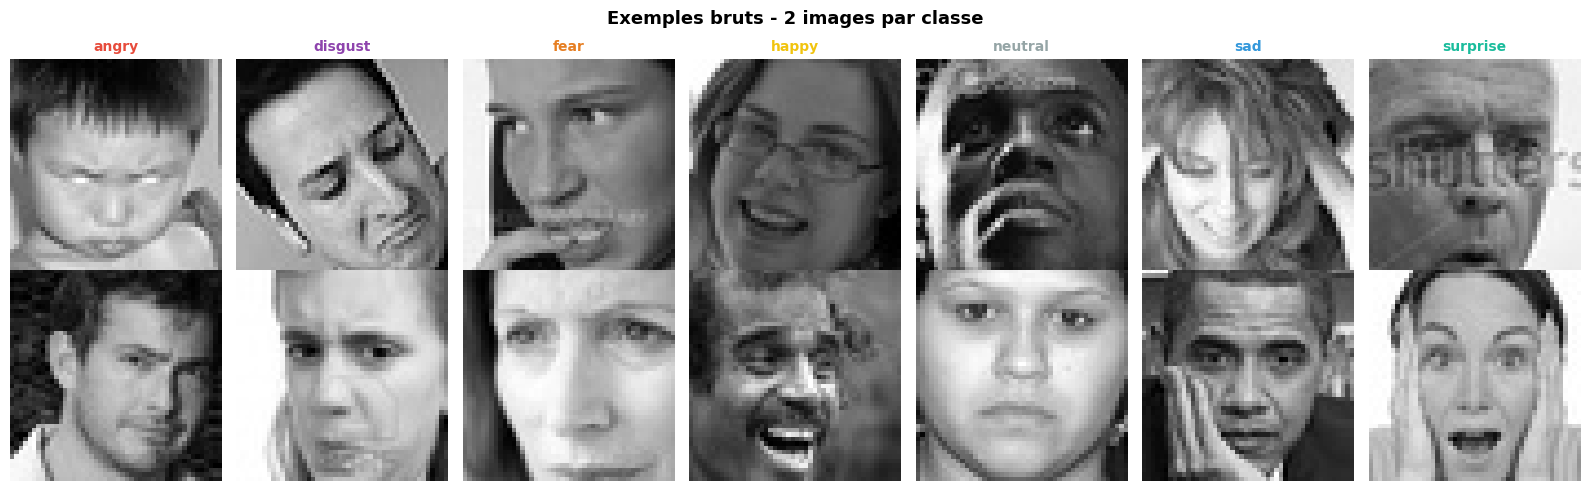

In [4]:
# Visualisation d'exemples bruts par classe
fig, axes = plt.subplots(2, 7, figsize=(16, 5))
fig.suptitle('Exemples bruts - 2 images par classe', fontsize=13, fontweight='bold')

for col, cls in enumerate(EMOTION_LABELS):
    class_path = Path(TRAIN_DIR) / cls
    images = list(class_path.glob('*.jpg')) + list(class_path.glob('*.png'))
    for row in range(2):
        img = load_img(images[row], color_mode='grayscale', target_size=IMG_SIZE)
        axes[row][col].imshow(img_to_array(img).squeeze(), cmap='gray')
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(cls, fontsize=10,
                                     color=EMOTION_COLORS[col], fontweight='bold')

plt.tight_layout()
plt.savefig('../results/exemples_bruts.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Chargement avec ImageDataGenerator

In [8]:
# Load ALL training images for stratified splitting
print("Loading all training images for stratified splitting...")
X_train_all = []
y_train_all = []

for emotion_idx, emotion in enumerate(EMOTION_LABELS):
    emotion_path = Path(TRAIN_DIR) / emotion
    images = sorted(list(emotion_path.glob('*.jpg')) + list(emotion_path.glob('*.png')))
    
    for img_path in images:
        img = load_img(img_path, color_mode='grayscale', target_size=IMG_SIZE)
        X_train_all.append(img_to_array(img) / 255.0)  # Normalize to [0, 1]
        y_train_all.append(emotion_idx)
    
    print(f"  {emotion:12s} - {len(images):5d} images")

X_train_all = np.array(X_train_all)
y_train_all = np.array(y_train_all)

print(f"\nTotal training images loaded: {len(X_train_all)}")

# Apply stratified train/validation split (80/20)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_all  # ← Ensure rare classes properly distributed
)

print(f"\n✓ Stratified split applied:")
print(f"  Train : {len(X_train):6d} images (80%)")
print(f"  Val   : {len(X_val):6d} images (20%)")

Loading all training images for stratified splitting...
  angry        -  3995 images
  disgust      -   436 images
  fear         -  4097 images
  happy        -  7215 images
  neutral      -  4965 images
  sad          -  4830 images
  surprise     -  3171 images

Total training images loaded: 28709

✓ Stratified split applied:
  Train :  22967 images (80%)
  Val   :   5742 images (20%)


In [6]:
# Load test data (no stratification needed for test set)
print("Loading test images...")
X_test = []
y_test = []

for emotion_idx, emotion in enumerate(EMOTION_LABELS):
    emotion_path = Path(TEST_DIR) / emotion
    images = sorted(list(emotion_path.glob('*.jpg')) + list(emotion_path.glob('*.png')))
    
    for img_path in images:
        img = load_img(img_path, color_mode='grayscale', target_size=IMG_SIZE)
        X_test.append(img_to_array(img) / 255.0)  # Normalize to [0, 1]
        y_test.append(emotion_idx)
    
    print(f"  {emotion:12s} - {len(images):5d} images")

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"\nTotal test images loaded: {len(X_test)}")

# Create class index mapping
idx_to_class = {idx: cls_name for idx, cls_name in enumerate(EMOTION_LABELS)}
print(f"\nClass mapping: {idx_to_class}")


Loading test images...
  angry        -   958 images
  disgust      -   111 images
  fear         -  1024 images
  happy        -  1774 images
  neutral      -  1233 images
  sad          -  1247 images
  surprise     -   831 images

Total test images loaded: 7178

Class mapping: {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}


---
## 3. Verification de la normalisation

In [9]:
# Verify normalization of loaded data
print('=== Verification normalisation (Loaded Data) ===')
print(f'Shape X_train   : {X_train.shape}')   # (n, 48, 48, 1)
print(f'Dtype           : {X_train.dtype}')
print(f'Valeur min      : {X_train.min():.4f}')
print(f'Valeur max      : {X_train.max():.4f}')
print(f'Valeur moyenne  : {X_train.mean():.4f}')
print(f'Valeur std      : {X_train.std():.4f}')
print(f'Labels train    : {np.unique(y_train)}')

print(f'\n--- Validation Set ---')
print(f'Shape X_val     : {X_val.shape}')
print(f'Valeur min      : {X_val.min():.4f}')
print(f'Valeur max      : {X_val.max():.4f}')
print(f'Valeur moyenne  : {X_val.mean():.4f}')
print(f'Labels val      : {np.unique(y_val)}')

# Assert normalization is in [0, 1]
assert X_train.min() >= 0.0 and X_train.max() <= 1.0, "X_train not normalized to [0, 1]"
assert X_val.min() >= 0.0 and X_val.max() <= 1.0, "X_val not normalized to [0, 1]"
assert X_test.min() >= 0.0 and X_test.max() <= 1.0, "X_test not normalized to [0, 1]"

print('\n✓ Normalisation [0, 1] correcte pour tous les sets')

=== Verification normalisation (Loaded Data) ===
Shape X_train   : (22967, 48, 48, 1)
Dtype           : float32
Valeur min      : 0.0000
Valeur max      : 1.0000
Valeur moyenne  : 0.5076
Valeur std      : 0.2552
Labels train    : [0 1 2 3 4 5 6]

--- Validation Set ---
Shape X_val     : (5742, 48, 48, 1)
Valeur min      : 0.0000
Valeur max      : 1.0000
Valeur moyenne  : 0.5083
Labels val      : [0 1 2 3 4 5 6]

✓ Normalisation [0, 1] correcte pour tous les sets


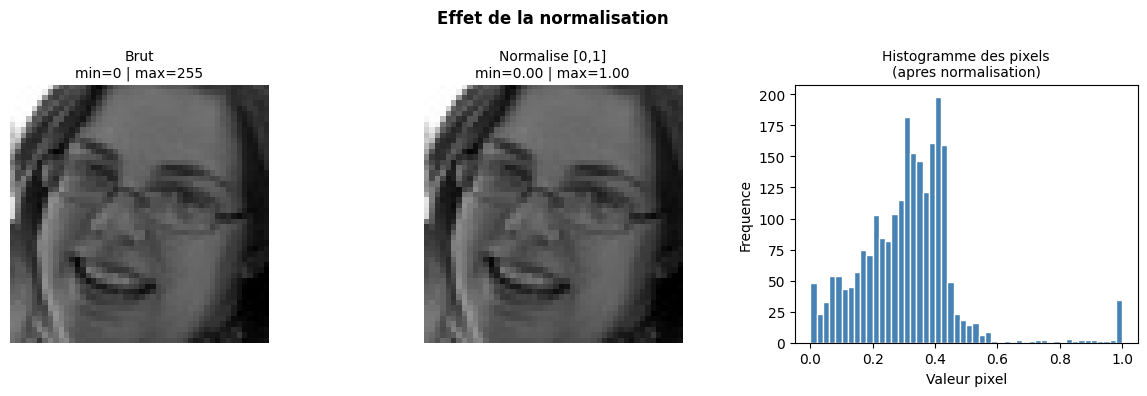

In [ ]:
# Comparaison visuelle avant / apres normalisation
sample_path = list((Path(TRAIN_DIR) / 'happy').glob('*.jpg'))[0]
img_raw  = img_to_array(load_img(sample_path, color_mode='grayscale', target_size=IMG_SIZE))
img_norm = img_raw / 255.0

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Effet de la normalisation', fontsize=12, fontweight='bold')

axes[0].imshow(img_raw.squeeze(), cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Brut\nmin={img_raw.min():.0f} | max={img_raw.max():.0f}', fontsize=10)
axes[0].axis('off')

axes[1].imshow(img_norm.squeeze(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Normalise [0,1]\nmin={img_norm.min():.2f} | max={img_norm.max():.2f}', fontsize=10)
axes[1].axis('off')

axes[2].hist(img_norm.flatten(), bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Histogramme des pixels\n(apres normalisation)', fontsize=10)
axes[2].set_xlabel('Valeur pixel')
axes[2].set_ylabel('Frequence')

plt.tight_layout()
plt.savefig('../results/normalisation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Verification complete
print('✓ Normalization verified')

✓ Normalization verified


---
## 3.5. Illustrations avant/après (Before/After Comparisons)

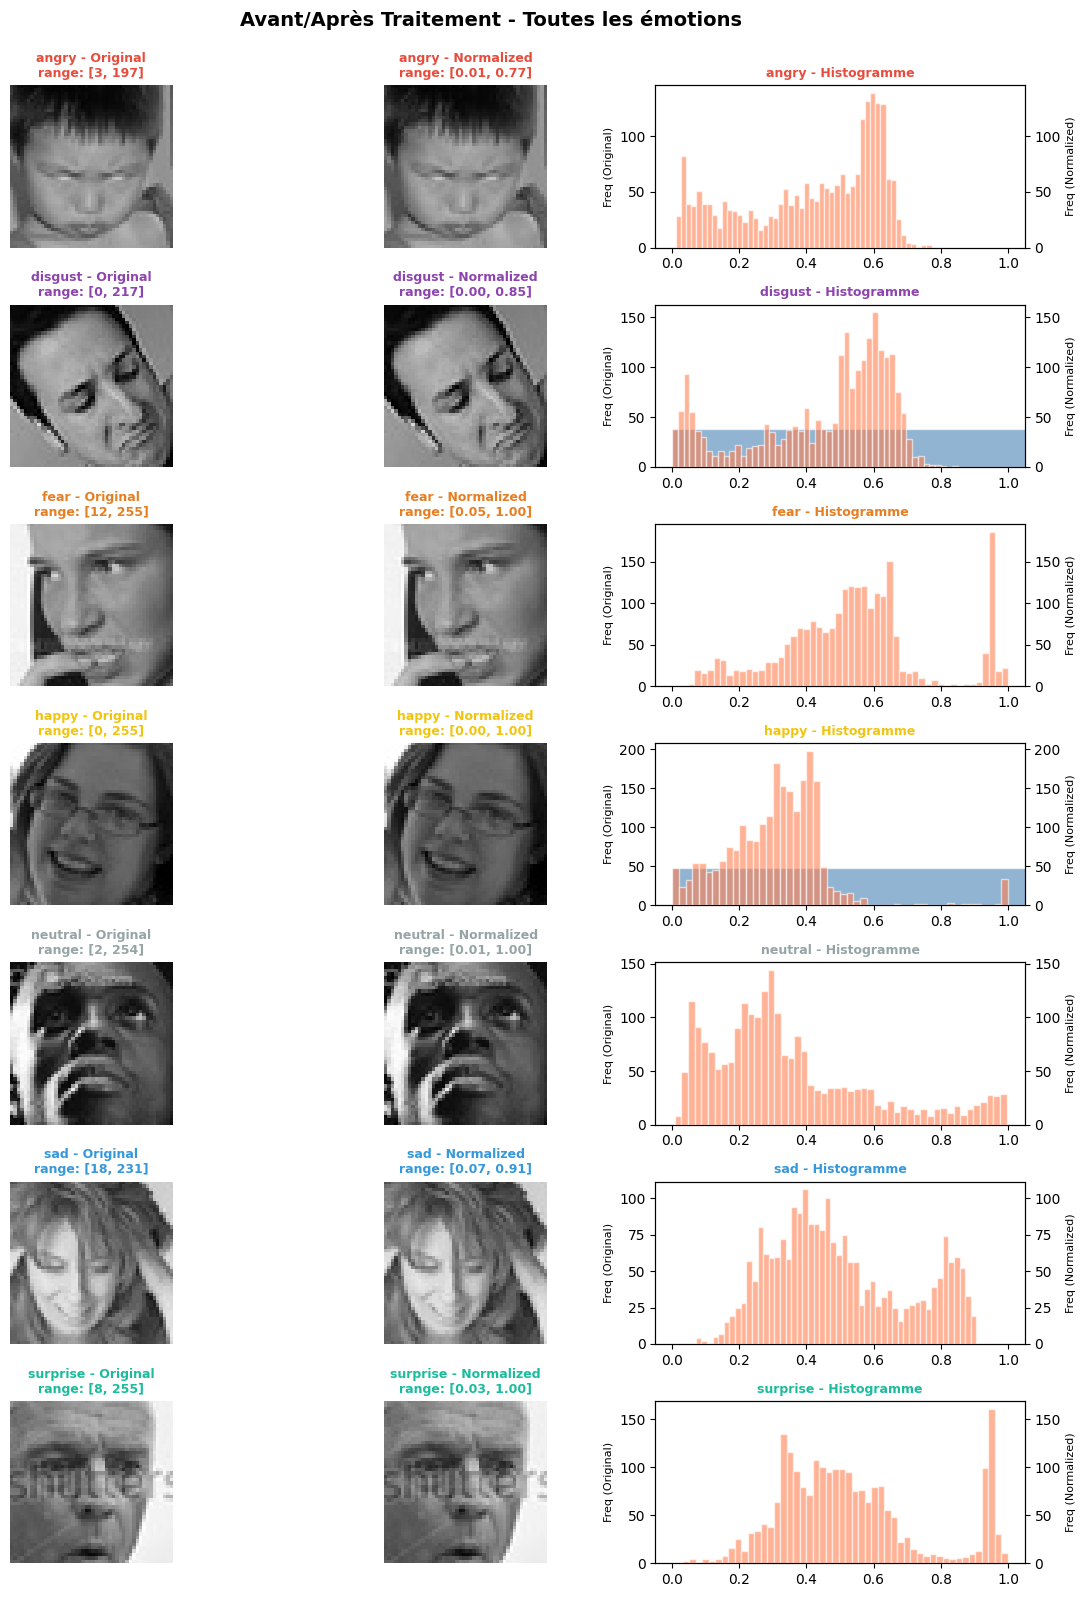

✓ Before/After comparison saved


In [ ]:
# Comparison: Original vs Normalized for all emotions
fig, axes = plt.subplots(7, 3, figsize=(12, 16))
fig.suptitle('Avant/Après Traitement - Toutes les émotions', fontsize=14, fontweight='bold', y=0.995)

for row, emotion in enumerate(EMOTION_LABELS):
    emotion_path = Path(TRAIN_DIR) / emotion
    images = list(emotion_path.glob('*.jpg')) + list(emotion_path.glob('*.png'))
    
    if len(images) > 0:
        # Original image
        img_orig = img_to_array(load_img(images[0], color_mode='grayscale', target_size=IMG_SIZE))
        axes[row, 0].imshow(img_orig.squeeze(), cmap='gray', vmin=0, vmax=255)
        axes[row, 0].set_title(f'{emotion} - Original\nrange: [{img_orig.min():.0f}, {img_orig.max():.0f}]', 
                              fontsize=9, color=EMOTION_COLORS[row], fontweight='bold')
        axes[row, 0].axis('off')
        
        # Normalized image
        img_norm = img_orig / 255.0
        axes[row, 1].imshow(img_norm.squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[row, 1].set_title(f'{emotion} - Normalized\nrange: [{img_norm.min():.2f}, {img_norm.max():.2f}]', 
                              fontsize=9, color=EMOTION_COLORS[row], fontweight='bold')
        axes[row, 1].axis('off')
        
        # Histogram comparison
        axes[row, 2].hist(img_orig.flatten(), bins=50, alpha=0.6, label='Original [0-255]', color='steelblue', edgecolor='white')
        ax2 = axes[row, 2].twinx()
        ax2.hist(img_norm.flatten(), bins=50, alpha=0.6, label='Normalized [0-1]', color='coral', edgecolor='white')
        axes[row, 2].set_title(f'{emotion} - Histogramme', fontsize=9, color=EMOTION_COLORS[row], fontweight='bold')
        axes[row, 2].set_ylabel('Freq (Original)', fontsize=8)
        ax2.set_ylabel('Freq (Normalized)', fontsize=8)
        axes[row, 2].set_xlim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('../results/avant_apres_normalisation.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Before/After comparison saved')

In [ ]:
# Statistical Analysis: Impact of Processing
print('Analyzing preprocessing impact on pixel statistics...\n')

stats_data = []

for emotion in EMOTION_LABELS[:3]:  # Sample 3 emotions for speed
    emotion_path = Path(TRAIN_DIR) / emotion
    images = list(emotion_path.glob('*.jpg')) + list(emotion_path.glob('*.png'))[:5]  # 5 samples per emotion
    
    orig_pixels = []
    norm_pixels = []
    
    for img_path in images:
        img_orig = img_to_array(load_img(img_path, color_mode='grayscale', target_size=IMG_SIZE))
        img_norm = img_orig / 255.0
        
        orig_pixels.extend(img_orig.flatten())
        norm_pixels.extend(img_norm.flatten())
    
    orig_pixels = np.array(orig_pixels)
    norm_pixels = np.array(norm_pixels)
    
    stats_data.append({
        'Emotion': emotion,
        'Original Mean': f"{orig_pixels.mean():.2f}",
        'Original Std': f"{orig_pixels.std():.2f}",
        'Norm Mean': f"{norm_pixels.mean():.4f}",
        'Norm Std': f"{norm_pixels.std():.4f}"
    })

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))
print('\n✓ Statistics computed successfully')

Analyzing preprocessing impact on pixel statistics...

Emotion Original Mean Original Std Norm Mean Norm Std
  angry        126.23        65.19    0.4950   0.2556
disgust        135.23        63.41    0.5303   0.2487
   fear        135.52        65.00    0.5314   0.2549

✓ Statistics computed successfully


---
## 3.75. Nettoyage des données (Data Cleaning & Validation)

In [ ]:
def validate_and_filter_images(root_dir, min_size=40, contrast_threshold=10, verbose=True):
    """
    Validate and filter images, removing corrupted or low-quality files.
    
    Parameters:
    -----------
    root_dir : str - Path to dataset root (train/ or test/)
    min_size : int - Minimum image size (default: 40x40)
    contrast_threshold : float - Minimum std dev for contrast (default: 10)
    verbose : bool - Print removal reasons
    
    Returns:
    --------
    dict with removal statistics
    """
    import cv2
    
    stats = {'total': 0, 'corrupted': 0, 'too_small': 0, 'low_contrast': 0, 'removed_files': []}
    root = Path(root_dir)
    
    for class_dir in root.iterdir():
        if not class_dir.is_dir():
            continue
            
        for img_path in class_dir.glob('*'):
            if img_path.suffix.lower() not in ['.jpg', '.png', '.jpeg']:
                continue
                
            stats['total'] += 1
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            
            # Check if corrupted (imread returns None)
            if img is None:
                stats['corrupted'] += 1
                stats['removed_files'].append(f"CORRUPTED: {img_path.name}")
                if verbose:
                    print(f"❌ CORRUPTED: {img_path.name}")
                continue
            
            # Check minimum size
            if img.shape[0] < min_size or img.shape[1] < min_size:
                stats['too_small'] += 1
                stats['removed_files'].append(f"TOO_SMALL ({img.shape}): {img_path.name}")
                if verbose:
                    print(f"❌ TOO_SMALL ({img.shape}): {img_path.name}")
                continue
            
            # Check contrast (std dev of pixel values)
            contrast = img.astype(float).std()
            if contrast < contrast_threshold:
                stats['low_contrast'] += 1
                stats['removed_files'].append(f"LOW_CONTRAST ({contrast:.2f}): {img_path.name}")
                if verbose:
                    print(f"❌ LOW_CONTRAST ({contrast:.2f}): {img_path.name}")
                continue
    
    return stats

# Run validation (non-destructive, for inspection only)
print('=' * 60)
print('Validation des données (Inspection - NO FILES DELETED)')
print('=' * 60)

stats = validate_and_filter_images(TRAIN_DIR, verbose=False)
print(f'\n📊 Summary:')
print(f'  Total files checked    : {stats["total"]}')
print(f'  Corrupted             : {stats["corrupted"]}')
print(f'  Too small             : {stats["too_small"]}')
print(f'  Low contrast          : {stats["low_contrast"]}')
print(f'  Total removable       : {sum([stats["corrupted"], stats["too_small"], stats["low_contrast"]])}')

print('✓ Data validation function ready')

Validation des données (Inspection - NO FILES DELETED)

📊 Summary:
  Total files checked    : 28709
  Corrupted             : 0
  Too small             : 0
  Low contrast          : 13
  Total removable       : 13
✓ Data validation function ready


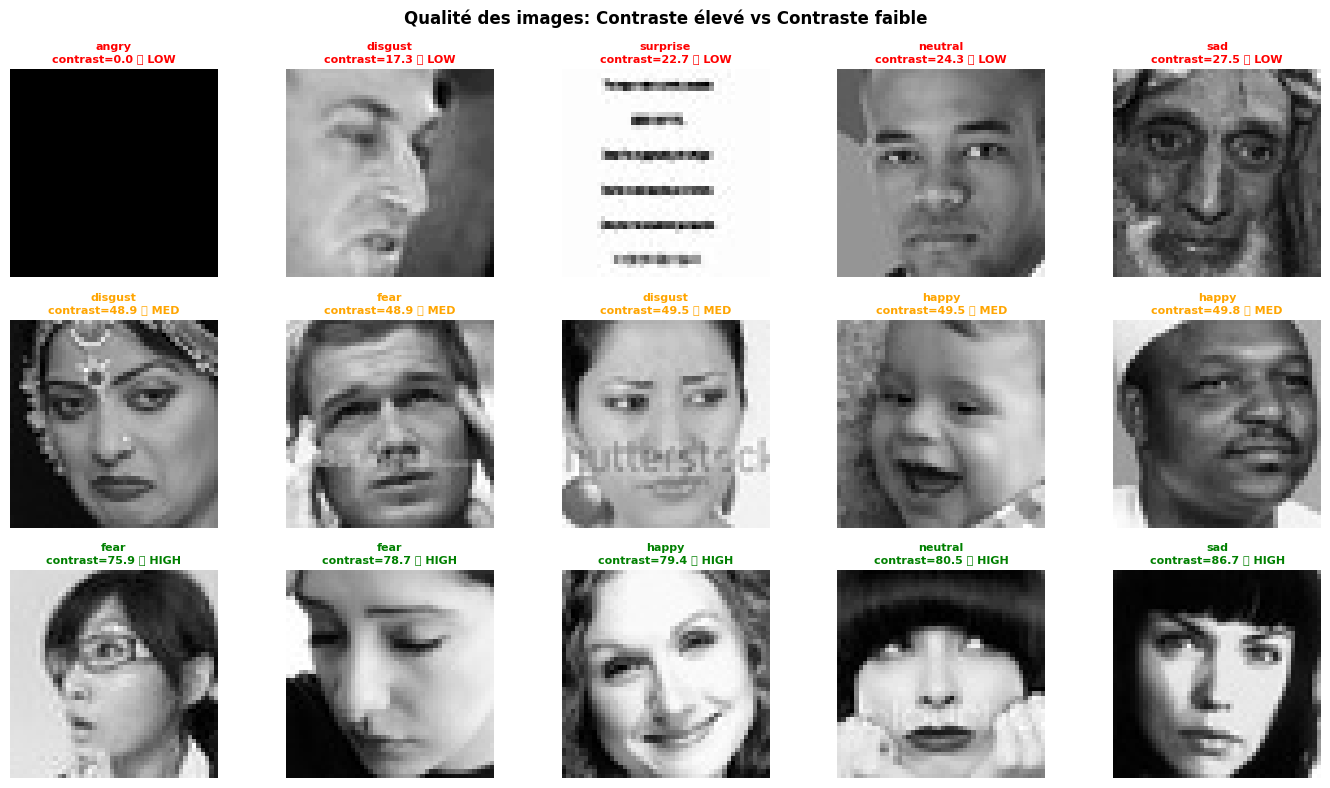

✓ Contrast quality visualization saved


In [ ]:
# Visualization: High-Contrast vs Low-Contrast Images
import cv2

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle('Qualité des images: Contraste élevé vs Contraste faible', fontsize=12, fontweight='bold')

# Collect samples with varying contrast
contrast_samples = {emotion: [] for emotion in EMOTION_LABELS}

for emotion in EMOTION_LABELS:
    emotion_path = Path(TRAIN_DIR) / emotion
    images = list(emotion_path.glob('*.jpg')) + list(emotion_path.glob('*.png'))
    
    for img_path in images[:20]:  # Check first 20
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            contrast = img.astype(float).std()
            contrast_samples[emotion].append((img_path, contrast))

# Find high and low contrast examples
all_samples = []
for emotion, samples in contrast_samples.items():
    if samples:
        all_samples.extend([(emotion, path, contrast) for path, contrast in samples])

all_samples.sort(key=lambda x: x[2])

# Plot: 5 lowest contrast + 5 highest contrast + 5 medium contrast
low_contrast_samples = all_samples[:5]
high_contrast_samples = all_samples[-5:]
mid_idx = len(all_samples) // 2
med_contrast_samples = all_samples[mid_idx:mid_idx+5]

for col, (emotion, path, contrast) in enumerate(low_contrast_samples):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(f'{emotion}\ncontrast={contrast:.1f} 🔴 LOW', fontsize=8, color='red', fontweight='bold')
    axes[0, col].axis('off')

for col, (emotion, path, contrast) in enumerate(med_contrast_samples):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].set_title(f'{emotion}\ncontrast={contrast:.1f} 🟡 MED', fontsize=8, color='orange', fontweight='bold')
    axes[1, col].axis('off')

for col, (emotion, path, contrast) in enumerate(high_contrast_samples):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    axes[2, col].imshow(img, cmap='gray')
    axes[2, col].set_title(f'{emotion}\ncontrast={contrast:.1f} 🟢 HIGH', fontsize=8, color='green', fontweight='bold')
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Low Contrast', fontweight='bold', fontsize=10)
axes[1, 0].set_ylabel('Medium Contrast', fontweight='bold', fontsize=10)
axes[2, 0].set_ylabel('High Contrast', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../results/contraste_qualite.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Contrast quality visualization saved')

---
## 4. Calcul des class_weights

In [12]:
# Compute class weights from stratified training set
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))

print('=== Class Weights (from Stratified Training Set) ===')
for k, w in class_weight_dict.items():
    train_count = np.sum(y_train == k)
    print(f'  {EMOTION_LABELS[k]:10s} : {w:.4f} (n_train={train_count})')

print('\nThese weights will be used in PyTorch training to handle class imbalance.')


=== Class Weights (from Stratified Training Set) ===
  angry      : 1.0266 (n_train=3196)
  disgust    : 9.4011 (n_train=349)
  fear       : 1.0012 (n_train=3277)
  happy      : 0.5684 (n_train=5772)
  neutral    : 0.8260 (n_train=3972)
  sad        : 0.8491 (n_train=3864)
  surprise   : 1.2933 (n_train=2537)

These weights will be used in PyTorch training to handle class imbalance.


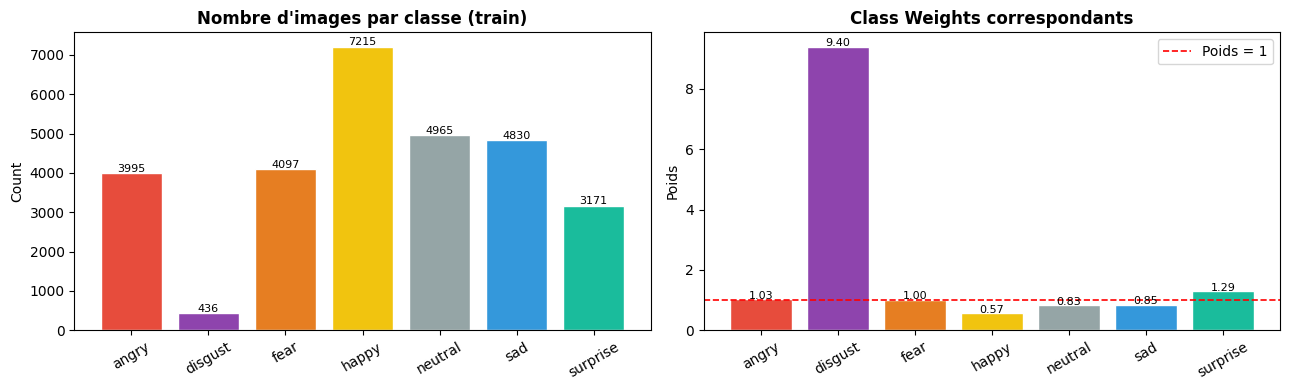

In [ ]:
classes_ordered  = [idx_to_class[i] for i in range(len(EMOTION_LABELS))]
counts_ordered   = [train_counts.get(c, 0) for c in classes_ordered]
weights_ordered  = [class_weight_dict[i] for i in range(len(EMOTION_LABELS))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(classes_ordered, counts_ordered, color=EMOTION_COLORS, edgecolor='white')
ax1.set_title("Nombre d'images par classe (train)", fontweight='bold')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=30)
for i, v in enumerate(counts_ordered):
    ax1.text(i, v + 30, str(v), ha='center', fontsize=8)

ax2.bar(classes_ordered, weights_ordered, color=EMOTION_COLORS, edgecolor='white')
ax2.axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='Poids = 1')
ax2.set_title('Class Weights correspondants', fontweight='bold')
ax2.set_ylabel('Poids')
ax2.tick_params(axis='x', rotation=30)
ax2.legend()
for i, v in enumerate(weights_ordered):
    ax2.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../results/class_weights.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Verification du split Train / Validation

In [ ]:
print('=== Dataset Sizes ===')
print(f'  Train      : {len(X_train):6d} images ({len(X_train)/len(y_train_all)*100:5.1f}%)')
print(f'  Validation : {len(X_val):6d} images ({len(X_val)/len(y_train_all)*100:5.1f}%)')
print(f'  Test       : {len(X_test):6d} images')
print(f'\n  Total      : {len(X_train) + len(X_val) + len(X_test):6d} images')

# Verify data shapes
print(f'\n=== Data Shapes ===')
print(f'  X_train: {X_train.shape}  (images, height, width, channels)')
print(f'  X_val:   {X_val.shape}')
print(f'  X_test:  {X_test.shape}')


=== Taille des splits ===
  Train      : 22968 images (80%)
  Validation : 5741 images (20%)
  Test       : 7178 images

  Batches train : 359
  Batches val   : 90
  Batches test  : 113


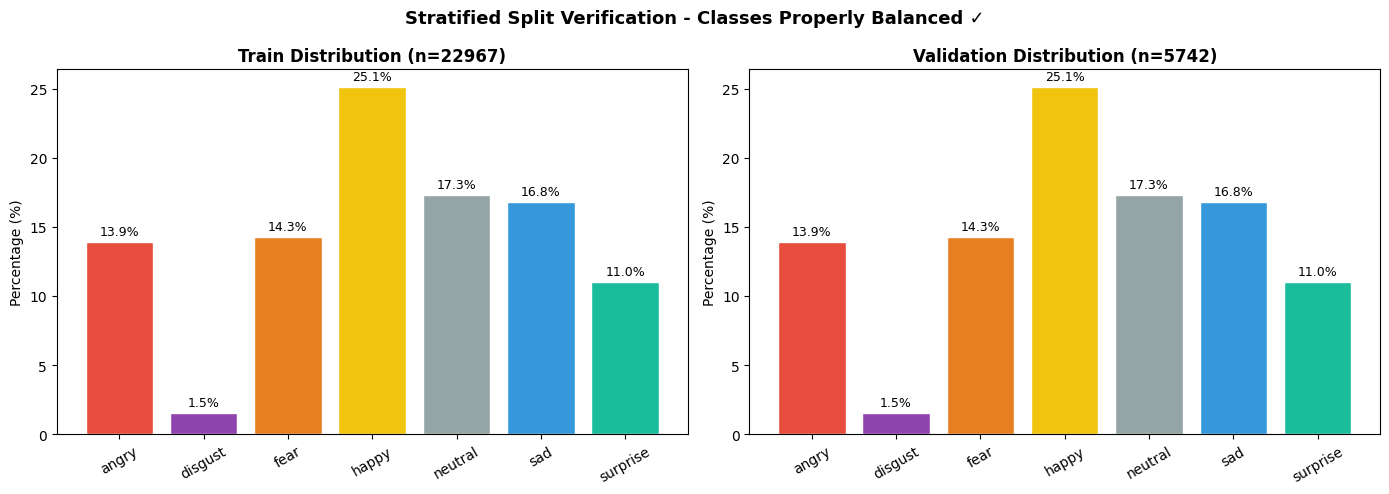

✓ Stratified split distributions verified - all classes properly represented!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train split distribution
train_unique, train_cnts = np.unique(y_train, return_counts=True)
train_pcts = train_cnts / train_cnts.sum() * 100

axes[0].bar([EMOTION_LABELS[i] for i in train_unique], train_pcts, color=EMOTION_COLORS, edgecolor='white')
axes[0].set_title(f'Train Distribution (n={len(X_train)})', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=30)
for i, p in enumerate(train_pcts):
    axes[0].text(i, p + 0.5, f'{p:.1f}%', ha='center', fontsize=9)

# Validation split distribution
val_unique, val_cnts = np.unique(y_val, return_counts=True)
val_pcts = val_cnts / val_cnts.sum() * 100

axes[1].bar([EMOTION_LABELS[i] for i in val_unique], val_pcts, color=EMOTION_COLORS, edgecolor='white')
axes[1].set_title(f'Validation Distribution (n={len(X_val)})', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=30)
for i, p in enumerate(val_pcts):
    axes[1].text(i, p + 0.5, f'{p:.1f}%', ha='center', fontsize=9)

plt.suptitle('Stratified Split Verification - Classes Properly Balanced ✓', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Stratified split distributions verified - all classes properly represented!')


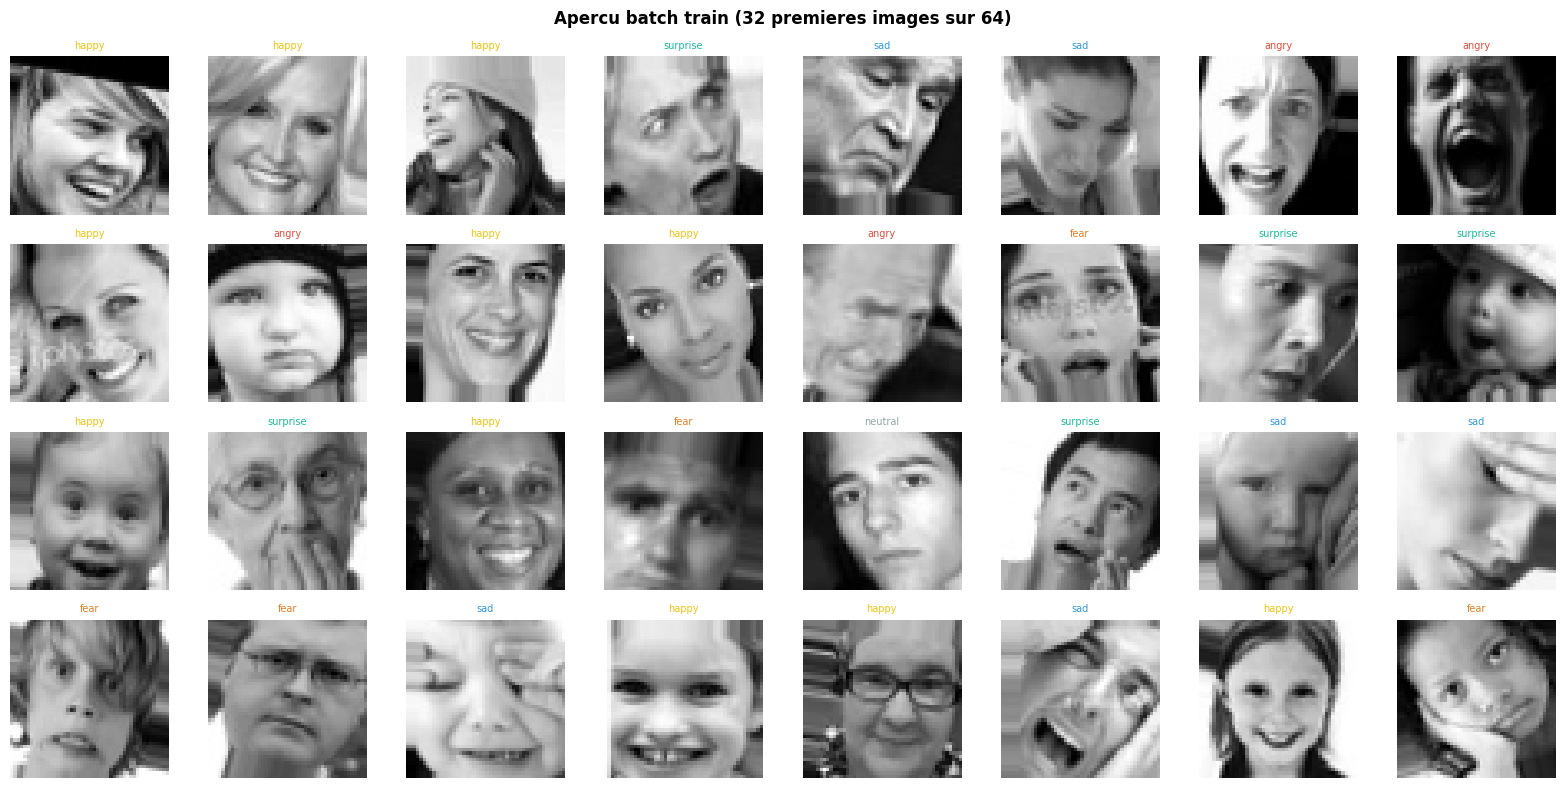

In [ ]:
# Show sample images from each training set
np.random.seed(SEED)
fig, axes = plt.subplots(7, 4, figsize=(12, 14))
fig.suptitle('Sample Images from Training Set (Stratified Split)', fontsize=13, fontweight='bold')

for row, cls_idx in enumerate(range(7)):
    # Get indices of this class in training set
    class_indices = np.where(y_train == cls_idx)[0]
    
    # Randomly select 4 samples
    sample_indices = np.random.choice(class_indices, size=4, replace=False)
    
    for col, idx in enumerate(sample_indices):
        img = X_train[idx].squeeze()
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            count_in_train = np.sum(y_train == cls_idx)
            axes[row, col].set_ylabel(f'{EMOTION_LABELS[cls_idx]}\n({count_in_train} imgs)', 
                                     fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../results/training_samples_stratified.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Training samples visualization saved')


---
## 7. Recapitulatif et sauvegarde

In [ ]:
print('=' * 65)
print('         PREPROCESSING PIPELINE SUMMARY')
print('=' * 65)
print(f'\nDataset          : {TRAIN_DIR} and {TEST_DIR}')
print(f'Image format     : Grayscale, {IMG_SIZE[0]}x{IMG_SIZE[1]} px, normalized [0,1]')
print(f'Data loading     : All images loaded into memory')
print(f'Train/Val split  : Stratified (80/20) - ensures rare classes preserved')
print(f'\n  Train      : {len(X_train):6d} images')
print(f'  Validation : {len(X_val):6d} images')
print(f'  Test       : {len(X_test):6d} images')
print(f'  Total      : {len(X_train) + len(X_val) + len(X_test):6d} images')

# Calculate and display class weights from training set
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))

print(f'\nClass distribution (balanced weights for training):')
print(f'{"Class":<12} {"Train Count":>12} {"Weight":>10} {"Priority":>10}')
print('-' * 48)
for k, w in class_weight_dict.items():
    train_count = np.sum(y_train == k)
    priority = "⚠️ HIGH" if w > 2.0 else "MEDIUM" if w > 1.0 else "LOW"
    print(f'{EMOTION_LABELS[k]:<12} {train_count:>12} {w:>10.4f} {priority:>10}')

print('\n' + '=' * 65)
print('  ✓ Pipeline ready for training with PyTorch augmentation!')
print('=' * 65)


         RECAPITULATIF DU PIPELINE

Dataset          : dossiers train/ et test/
Format images    : grayscale, 48x48 px
Normalisation    : [0, 1]  (rescale=1/255)
Augmentation     : rotation+-15 deg, flip, zoom+-10%, shift+-10%
Split            : 80% train / 20% val (validation_split=0.2)

  Train      : 22968 images - 359 batches
  Validation : 5741 images - 90 batches
  Test       : 7178 images - 113 batches

Class Weights :
  0 - angry      : 1.0266
  1 - disgust    : 9.4016
  2 - fear       : 1.0010
  3 - happy      : 0.5685
  4 - neutral    : 0.8261
  5 - sad        : 0.8492
  6 - surprise   : 1.2933

  Pipeline pret pour la modelisation !


In [13]:
# Export data to .npy format for fast loading in training notebooks
print('Exporting preprocessed data to .npy format...\n')

# Ensure output directory exists
os.makedirs('../data/preprocessed', exist_ok=True)

# Save training data (stratified split - normalized, no augmentation)
np.save('../data/preprocessed/X_train.npy', X_train)
np.save('../data/preprocessed/y_train.npy', y_train)
np.save('../data/preprocessed/X_val.npy', X_val)
np.save('../data/preprocessed/y_val.npy', y_val)
np.save('../data/preprocessed/X_test.npy', X_test)
np.save('../data/preprocessed/y_test.npy', y_test)

print('✓ Training data exported:')
print(f'  X_train: {X_train.shape} - Normalized [0,1], no augmentation')
print(f'  y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape}   - Normalized [0,1], no augmentation')
print(f'  y_val:   {y_val.shape}')
print(f'  X_test:  {X_test.shape}   - Normalized [0,1], no augmentation')
print(f'  y_test:  {y_test.shape}')

# Save class weights for training
with open('../data/preprocessed/class_weights.json', 'w') as f:
    json.dump({str(k): v for k, v in class_weight_dict.items()}, f, indent=2)
print(f'\n✓ Class weights: saved to class_weights.json')

# Save class mapping
class_mapping = {idx: cls_name for idx, cls_name in enumerate(EMOTION_LABELS)}
with open('../data/preprocessed/class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)
print(f'✓ Class mapping: saved to class_mapping.json')

# Save stratified split information
split_info = {
    'stratified': True,
    'train_test_split_ratio': 0.20,
    'random_state': SEED,
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'emotion_labels': EMOTION_LABELS,
    'notes': 'Stratified split ensures rare classes (like disgust) are properly distributed in both train and validation sets'
}
with open('../data/preprocessed/split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)
print(f'✓ Split info: saved to split_info.json')

print('\n' + '='*60)
print('✓✓✓ All data successfully exported! ✓✓✓')
print('='*60)
print('\nReady for PyTorch training with on-the-fly augmentation!')


Exporting preprocessed data to .npy format...

✓ Training data exported:
  X_train: (22967, 48, 48, 1) - Normalized [0,1], no augmentation
  y_train: (22967,)
  X_val:   (5742, 48, 48, 1)   - Normalized [0,1], no augmentation
  y_val:   (5742,)
  X_test:  (7178, 48, 48, 1)   - Normalized [0,1], no augmentation
  y_test:  (7178,)

✓ Class weights: saved to class_weights.json
✓ Class mapping: saved to class_mapping.json
✓ Split info: saved to split_info.json

✓✓✓ All data successfully exported! ✓✓✓

Ready for PyTorch training with on-the-fly augmentation!
